<h1> GlobalExpress — Delivery Efficiency Analysis </h1>

<b>Goal: Analyze delivery efficiency to answer:</b>

<li>What factors have the strongest influence on delivery times?</li>

<li>How do weather and traffic conditions affect delivery performance?</li>

<li>Are there specific delivery zones with consistently poor performance?</li>

In [143]:
# Imports & settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display, Markdown
# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 2000)

# Display a dataframe in scrollable style.
def show_scrollable(df, n=50, max_height=260):
    
    scrollable_style = (
        f'style="display:block; overflow-x:auto; max-height:{max_height}px; '
        f'overflow-y:auto; white-space:nowrap"'
    )
    display(df.head(n).style.set_table_attributes(scrollable_style))

In [144]:
# Load the uploaded datasets
deliveries_df = pd.read_csv('gex_data/data_deliveries.csv')
drivers_df = pd.read_csv('gex_data/data_drivers.csv')
warehouses_df = pd.read_csv('gex_data/data_warehouses.csv')
zones_df = pd.read_csv('gex_data/data_zones.csv')

# Quick overview of data

In [ ]:
show_scrollable(deliveries_df, 50)
show_scrollable(drivers_df, 50)
show_scrollable(warehouses_df, 9)
show_scrollable(zones_df, 31)

,package_id,date,time_of_day,driver_id,warehouse_id,delivery_zone_id,package_type,package_weight,package_width,package_height,package_depth,package_value,promised_delivery_time,actual_delivery_time,delivery_status,customer_rating,weather_condition,traffic_condition,fuel_consumption,vehicle_type,is_return_trip,customer_id,payment_method,promotional_code_used,is_new_customer,package_insurance,has_mobile_notification,delivery_cost,profitability,optimization_factor
0,6fa6b079,2025-03-13,11:00,D037,W06,Z29,Standard,11.860000,33.100000,40.200000,23.200000,898.920000,22.000000,23.100000,Slightly Delayed,4.500000,Windy,Moderate,0.250000,Motorcycle,False,C5766,PayPal,True,False,True,True,15.900000,22.400000,0.533834
1,b3d5e13e,2025-01-31,18:37,D036,W02,Z30,Same-day,7.340000,29.300000,20.800000,32.900000,223.060000,7.000000,7.800000,Slightly Delayed,3.500000,Rainy,Moderate,0.550000,Motorcycle,False,C4308,Invoice,False,False,False,True,41.150000,-21.000000,0.825857
2,efa0e968,2025-03-05,17:13,D030,W08,Z13,Heavy,19.040000,13.300000,64.200000,59.800000,368.860000,0.600000,11.800000,Significantly Delayed,2.500000,Clear,Severe,0.000000,Bicycle,False,C8589,Invoice,False,True,False,False,24.380000,-13.240000,0.469083
3,456ce96c,2025-03-14,09:40,D019,W01,Z21,Standard,1.760000,86.700000,85.700000,69.200000,168.800000,6.000000,8.000000,Significantly Delayed,3.500000,Rainy,Moderate,2.350000,Truck,False,C7623,Invoice,False,False,True,True,15.980000,-13.950000,0.906490
4,5d75bce0,2025-01-31,14:02,D024,W08,Z 10,Heavy,26.720000,12.900000,31.600000,92.600000,459.640000,23.000000,29.100000,Significantly Delayed,2.500000,Stormy,Heavy,2.200000,Van,False,C8546,Invoice,False,False,False,True,22.430000,-27.200000,0.888381
5,fd0aa851,2025-03-31,13:46,D028,W08,Z23,Fragile,0.480000,92.200000,73.100000,13.800000,nan,0.383333,22.500000,Significantly Delayed,5.000000,Clear,Light,0.000000,Bicycle,False,C9058,Credit Card,False,False,False,True,15.260000,nan,0.530973
6,9c1bf4fe,2025-03-11,12:13,D048,W08,Z06,Same-day,2.900000,88.000000,52.900000,17.800000,927.650000,170.000000,18.700000,On Time,nan,Cloudy,Light,2.900000,Van,False,C5082,Invoice,False,False,False,True,50.780000,1.970000,0.215969
7,da68b0bc,2025-02-21,11:22,D003,W03,Z16,Standard,9.750000,52.700000,53.900000,74.600000,871.820000,20.000000,21.400000,Slightly Delayed,3.500000,Cloudy,Heavy,0.480000,Van,False,C4257,Invoice,False,True,False,False,11.990000,-23.570000,0.463000
8,a225656b,2025-01-15,10:08,D020,W03,Z04,Fragile,11.360000,89.000000,12.400000,42.200000,288.520000,1.900000,22.100000,Slightly Delayed,3.500000,Clear,Light,nan,Bicycle,False,C1873,Cash,False,False,False,True,30.150000,nan,0.711375
9,704b8e19,2025-01-01,10:49,D044,W07,Z06,Refrigerated,5.590000,18.500000,66.900000,91.000000,675.700000,0.500000,11.100000,Significantly Delayed,2.500000,Snowy,Light,0.000000,Bicycle,True,C4428,Invoice,False,False,False,True,36.690000,-9.870000,0.581541


,driver_id,driver_name,license_number,driver_rating,years_experience,vehicle_type,home_warehouse,shift_preference,max_packages_per_day,has_refrigeration_unit,last_training_date,salary_tier,bonus_eligible
0,D001,Driver 1,L31068,4.050000,1,Motorcycle,W08,Night,27,False,2025-02-10,3,True
1,D002,Driver 2,L44164,4.000000,4,Motorcycle,W03,Afternoon,58,False,2025-02-11,2,True
2,D003,Driver 3,L99368,4.750000,1,Van,W05,Morning,84,True,2025-02-12,2,True
3,D004,Driver 4,L45188,5.000000,5,Truck,W07,Morning,78,True,2025-02-13,3,True
4,D005,Driver 5,L60504,4.080000,9,Van,W03,Morning,22,True,2025-02-14,3,True
5,D006,Driver 6,L75115,4.580000,6,Motorcycle,W04,Evening,62,False,2025-02-15,2,True
6,D007,Driver 7,L68996,3.650000,9,Truck,W03,Evening,56,False,2025-02-16,3,True
7,D008,Driver 8,L50638,4.370000,10,Truck,W02,Afternoon,26,True,2025-02-17,3,True
8,D009,Driver 9,L63266,4.080000,4,Truck,W03,Morning,48,False,2025-02-18,1,False
9,D010,Driver 10,L45161,4.580000,3,Bicycle,W06,Afternoon,84,False,2025-02-19,2,True


,warehouse_id,warehouse_name,capacity,location_latitude,location_longitude,operating_hours,manager_id,refrigeration_capacity,has_automated_sorting,maintenance_schedule,electricity_cost
0,W01,Warehouse A,3597,40.802807,-73.961812,06:00-22:00,M01,1051,True,Weekly,3677.700000
1,W02,Warehouse B,3301,40.791033,-73.655684,06:00-24:00,M02,961,False,Weekly,1832.350000
2,W03,Warehouse C,1768,40.943624,-73.797968,06:00-24:00,M03,191,True,Monthly,1661.770000
3,W04,Warehouse D,1461,40.806129,-73.816070,06:00-24:00,M04,302,False,Weekly,3020.370000
4,W05,Warehouse E,2761,40.516460,-73.625285,06:00-22:00,M05,697,True,Weekly,3613.900000
5,W06,Warehouse F,4214,40.662525,-73.907723,06:00-18:00,M06,829,False,Monthly,1068.250000
6,W07,Warehouse G,1416,40.778103,-73.729133,06:00-24:00,M07,239,True,Monthly,4032.780000
7,W08,Warehouse H,1013,40.533399,-73.694002,06:00-20:00,M08,198,True,Bi-weekly,3072.860000


,zone_id,zone_name,distance_from_hub,population,avg_income,urban_density,primary_warehouse,zone_type,avg_delivery_time,parking_difficulty,zone_growth_rate
0,Z01,Zone 1,10.600000,24762,36568.360000,Medium,W02,Commercial,3.500000,3,-0.035200
1,Z02,Zone 2,14.100000,7171,31920.300000,High,W05,Residential,3.400000,5,0.030100
2,Z03,Zone 3,7.600000,89059,93144.320000,Low,W07,Industrial,3.500000,4,0.099800
3,Z04,Zone 4,23.600000,12181,104107.950000,Low,W07,Commercial,4.000000,4,0.004300
4,Z05,Zone 5,2.400000,92743,110107.320000,Medium,W07,Industrial,4.800000,5,0.115400
5,Z06,Zone 6,23.700000,99890,84975.820000,High,W08,Industrial,1.300000,4,0.011900
6,Z07,Zone 7,10.600000,65368,51698.980000,Low,W04,Mixed,4.700000,5,0.096900
7,Z08,Zone 8,10.700000,49074,78105.110000,Low,W06,Mixed,5.000000,4,0.078800
8,Z09,Zone 9,5.600000,96863,107123.260000,Low,W06,Industrial,1.800000,3,0.049800
9,Z10,Zone 10,13.900000,25064,87757.500000,Low,W03,Commercial,1.500000,2,0.041400


<b>Note: Some delivery zone IDs have spacing inconsistencies (e.g., 'Z 10' vs 'Z10').</b>

<h1>Data Understaning and Quality Check </h1>

In [146]:
# Check basic information(shape, dtypes, missing values, duplicates.)
def check_basic_info(df, name):
    
    display(Markdown(f"### Basic Info: {name}"))
    print("Shape:", df.shape)
    print("\nData Types:\n", df.dtypes)
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (df.isnull().mean() * 100).round(2)
    print("\nMissing Values:\n", pd.DataFrame({"Missing": missing, "Pct": missing_pct}))
    
    # Duplicates
    print("\nDuplicate Rows:", df.duplicated().sum())

#Ensure ID columns are unique where expected.
def check_unique_id(df, col, name):
    
    unique_count = df[col].nunique()
    total_count = len(df)
    if unique_count == total_count:
        print(f"✅ {name}: `{col}` is unique")
    else:
        print(f"⚠️ {name}: `{col}` has duplicates ({total_count-unique_count} issues)")
   

In [147]:
# Check categorical fields against allowed values.
def check_allowed_values(df, col, allowed, name):
  
    invalid = set(df[col].dropna().unique()) - set(allowed)
    if not invalid:
        print(f"✅ {name}: `{col}` values are valid")
    else:
        print(f"⚠️ {name}: `{col}` has invalid values → {invalid}")
    

In [148]:
#  Check if numeric columns fall within expected ranges.
def check_numeric_ranges(df, col, min_val=None, max_val=None, allow_zero=True, name=""):
    issues = False  # track if any problem is found
    
    if min_val is not None:
        below_min = df[df[col] < min_val]
        if len(below_min) > 0:
            print(f"⚠️ {name}: `{col}` has {len(below_min)} values below {min_val}")
            issues = True

    if not allow_zero:
        zero_vals = (df[col] == 0).sum()
        if zero_vals > 0:
            print(f"⚠️ {name}: `{col}` has {zero_vals} zero values where not allowed")
            issues = True

    if max_val is not None:
        above_max = df[df[col] > max_val]
        if len(above_max) > 0:
            print(f"⚠️ {name}: `{col}` has {len(above_max)} values above {max_val}")
            issues = True

    if not issues:
        print(f"✅ {name}: `{col}` values are within the expected range")


In [149]:
# Deliveries Dataset Checks

check_basic_info(deliveries_df, "Deliveries")
print("-"*60, "\n")
check_unique_id(deliveries_df, "package_id", "Deliveries")

print("-"*60, "\n")
# Allowed categories
check_allowed_values(deliveries_df, "package_type", ["Standard","Express","Same-day","Fragile","Heavy","Refrigerated"], "Deliveries")
check_allowed_values(deliveries_df, "delivery_status", ["On Time","Slightly Delayed","Significantly Delayed"], "Deliveries")
check_allowed_values(deliveries_df, "weather_condition", ["Clear","Cloudy","Rainy","Stormy","Snowy","Foggy","Windy"], "Deliveries")
check_allowed_values(deliveries_df, "traffic_condition", ["Light","Moderate","Heavy","Severe"], "Deliveries")
check_allowed_values(deliveries_df, "payment_method", ["Credit Card","Cash","PayPal","Invoice"], "Deliveries")
print("-"*60, "\n")
# Numeric ranges
check_numeric_ranges(deliveries_df, "package_weight", 0, None, False, "Deliveries")
check_numeric_ranges(deliveries_df, "package_value", 0, None, False, "Deliveries")
check_numeric_ranges(deliveries_df, "promised_delivery_time", 0, None, False, "Deliveries")
check_numeric_ranges(deliveries_df, "actual_delivery_time", 0, None, False, "Deliveries")
check_numeric_ranges(deliveries_df, "customer_rating", 1, 5, True, "Deliveries")
check_numeric_ranges(deliveries_df, "optimization_factor", 0, 1, True, "Deliveries")



### Basic Info: Deliveries

Shape: (45000, 30)

Data Types:
 package_id                  object
date                        object
time_of_day                 object
driver_id                   object
warehouse_id                object
delivery_zone_id            object
package_type                object
package_weight             float64
package_width              float64
package_height             float64
package_depth              float64
package_value              float64
promised_delivery_time     float64
actual_delivery_time       float64
delivery_status             object
customer_rating            float64
weather_condition           object
traffic_condition           object
fuel_consumption           float64
vehicle_type                object
is_return_trip                bool
customer_id                 object
payment_method              object
promotional_code_used         bool
is_new_customer               bool
package_insurance             bool
has_mobile_notification       bool
delivery_cost         

In [150]:
# Show  rows where package_id is duplicated
duplicates = deliveries_df[deliveries_df.duplicated(subset=["package_id"], keep=False)]

print(f"Total duplicate rows found: {len(duplicates)}")
display(duplicates)

Total duplicate rows found: 4


,package_id,date,time_of_day,driver_id,warehouse_id,delivery_zone_id,package_type,package_weight,package_width,package_height,package_depth,package_value,promised_delivery_time,actual_delivery_time,delivery_status,customer_rating,weather_condition,traffic_condition,fuel_consumption,vehicle_type,is_return_trip,customer_id,payment_method,promotional_code_used,is_new_customer,package_insurance,has_mobile_notification,delivery_cost,profitability,optimization_factor
8858,6f3665ec,2025-03-04,13:57,D040,W06,Z14,Heavy,11.39,55.3,91.0,58.6,604.21,140.0,17.3,On Time,2.5,Foggy,Moderate,NaN,Van,False,C6339,PayPal,False,False,False,False,27.42,NaN,0.706714
16492,6c92f5d0,2025-01-25,17:04,D027,W05,Z12,Fragile,16.02,62.8,14.5,70.6,393.33,22.0,28.4,Significantly Delayed,2.5,Clear,Severe,1.37,Motorcycle,False,C7390,PayPal,True,False,False,False,30.80,-22.79,0.230410
16639,6f3665ec,2025-03-20,16:22,D016,W03,Z17,Express,16.23,17.8,76.5,48.9,437.68,16.0,17.9,Slightly Delayed,3.5,Rainy,Heavy,1.12,Truck,False,C2794,Invoice,False,False,False,True,21.14,-14.94,0.365246
17641,6c92f5d0,2025-02-06,16:44,D047,W08,Z 15,Refrigerated,19.17,56.9,27.6,96.1,409.01,1.0,2.3,Significantly Delayed,2.5,Clear,Moderate,0.00,Bicycle,False,C9343,Credit Card,False,False,False,True,20.45,-11.47,0.271578


The Deliveries dataset shows ~5% missing values in key columns such as package_weight, package_value, customer_rating, and fuel_consumption , delivery_cost, with profitability missing in ~14% of records.
Additionally, package_id contains 2 duplicate entries(They are not exact duplicates — almost every other column differs). So i will not drop them but it need to further investigation why it happen.

In [151]:

# Drivers Dataset Checks

check_basic_info(drivers_df, "Drivers")
print("-"*60, "\n")
check_unique_id(drivers_df, "driver_id", "Drivers")
print("-"*60, "\n")
check_allowed_values(drivers_df, "shift_preference", ["Morning","Afternoon","Evening","Night"], "Drivers")
check_allowed_values(drivers_df, "salary_tier", [1,2,3,4], "Drivers")
print("-"*60, "\n")
check_numeric_ranges(drivers_df, "driver_rating", 1, 5, True, "Drivers")
check_numeric_ranges(drivers_df, "years_experience", 0, 60, True, "Drivers")  # assume <60 years



### Basic Info: Drivers

Shape: (50, 13)

Data Types:
 driver_id                  object
driver_name                object
license_number             object
driver_rating             float64
years_experience            int64
vehicle_type               object
home_warehouse             object
shift_preference           object
max_packages_per_day        int64
has_refrigeration_unit       bool
last_training_date         object
salary_tier                 int64
bonus_eligible               bool
dtype: object

Missing Values:
                         Missing  Pct
driver_id                     0  0.0
driver_name                   0  0.0
license_number                0  0.0
driver_rating                 0  0.0
years_experience              0  0.0
vehicle_type                  0  0.0
home_warehouse                0  0.0
shift_preference              0  0.0
max_packages_per_day          0  0.0
has_refrigeration_unit        0  0.0
last_training_date            0  0.0
salary_tier                   0  0.0
bonus_eligible 

In [152]:
# ------------------------

check_basic_info(warehouses_df, "Warehouses")
print("-"*60, "\n")
check_unique_id(warehouses_df, "warehouse_id", "Warehouses")
print("-"*60, "\n")

check_allowed_values(warehouses_df, "maintenance_schedule", ["Weekly","Bi-weekly","Monthly"], "Warehouses")

print("-"*60, "\n")
check_numeric_ranges(warehouses_df, "capacity", 0, None, False, "Warehouses")
check_numeric_ranges(warehouses_df, "electricity_cost", 0, None, False, "Warehouses")

### Basic Info: Warehouses

Shape: (8, 11)

Data Types:
 warehouse_id               object
warehouse_name             object
capacity                    int64
location_latitude         float64
location_longitude        float64
operating_hours            object
manager_id                 object
refrigeration_capacity      int64
has_automated_sorting        bool
maintenance_schedule       object
electricity_cost          float64
dtype: object

Missing Values:
                         Missing  Pct
warehouse_id                  0  0.0
warehouse_name                0  0.0
capacity                      0  0.0
location_latitude             0  0.0
location_longitude            0  0.0
operating_hours               0  0.0
manager_id                    0  0.0
refrigeration_capacity        0  0.0
has_automated_sorting         0  0.0
maintenance_schedule          0  0.0
electricity_cost              0  0.0

Duplicate Rows: 0
------------------------------------------------------------ 

✅ Warehouses: `warehouse_id` is unique


In [153]:
# Zones Dataset Checks

check_basic_info(zones_df, "Zones")
print("-"*60, "\n")
check_unique_id(zones_df, "zone_id", "Zones")
print("-"*60, "\n")
check_allowed_values(zones_df, "urban_density", ["High","Medium","Low"], "Zones")
check_allowed_values(zones_df, "zone_type", ["Residential","Commercial","Industrial","Mixed"], "Zones")
print("-"*60, "\n")
check_numeric_ranges(zones_df, "distance_from_hub", 0, None, False, "Zones")
check_numeric_ranges(zones_df, "population", 0, None, False, "Zones")
check_numeric_ranges(zones_df, "avg_income", 0, None, False, "Zones")
check_numeric_ranges(zones_df, "parking_difficulty", 1, 5, True, "Zones")



### Basic Info: Zones

Shape: (30, 11)

Data Types:
 zone_id                object
zone_name              object
distance_from_hub     float64
population              int64
avg_income            float64
urban_density          object
primary_warehouse      object
zone_type              object
avg_delivery_time     float64
parking_difficulty      int64
zone_growth_rate      float64
dtype: object

Missing Values:
                     Missing  Pct
zone_id                   0  0.0
zone_name                 0  0.0
distance_from_hub         0  0.0
population                0  0.0
avg_income                0  0.0
urban_density             0  0.0
primary_warehouse         0  0.0
zone_type                 0  0.0
avg_delivery_time         0  0.0
parking_difficulty        0  0.0
zone_growth_rate          0  0.0

Duplicate Rows: 0
------------------------------------------------------------ 

✅ Zones: `zone_id` is unique
------------------------------------------------------------ 

✅ Zones: `urban_density` values are va

<h1>Data Cleaning & Preparation</h1>

In [ ]:
# 1. Generic Helper Functions

# removes leading/trailing spaces from string columns.
def clean_string_columns(df, cols):
  
    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    return df

# Remove ONLY internal spaces from string columns.
def remove_internal_spaces(df, cols):

    for col in cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(" ", "", regex=False)
    
    return df

# Convert specified columns to datetime format.
def convert_to_datetime(df, cols):
    
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

# Convert specified columns to numeric .
def convert_to_numeric(df, cols):
    
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

# Replace negative values with NaN in specified numeric columns.
def enforce_non_negative(df, cols):
    
    for col in cols:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan
    return df

# Enforce allowed ranges for numeric columns.rules = { "col_name": (min_val, max_val, allow_zero)}
def enforce_ranges(df, rules):
   
    for col, (min_val, max_val, allow_zero) in rules.items():
        if col not in df.columns:
            continue
        # Below minimum
        if min_val is not None:
            df.loc[df[col] < min_val, col] = np.nan
        # Above maximum
        if max_val is not None:
            df.loc[df[col] > max_val, col] = np.nan
        # Zero check
        if not allow_zero:
            df.loc[df[col] == 0, col] = np.nan
    return df


In [155]:
# Cleaning for Deliveries Dataset

def clean_deliveries(deliveries_df):
    # String cleanup
    deliveries_df = clean_string_columns(deliveries_df, ["delivery_zone_id","warehouse_id","driver_id","customer_id"])
    
    deliveries_df = remove_internal_spaces(deliveries_df, ["delivery_zone_id"])
    
    # Datetime conversion
    deliveries_df = convert_to_datetime(deliveries_df, ["date"])
    
    # Numeric conversion
    num_cols = [
        "package_weight","package_width","package_height","package_depth",
        "package_value","promised_delivery_time","actual_delivery_time",
        "customer_rating","fuel_consumption","delivery_cost","profitability",
        "optimization_factor"
    ]
    deliveries_df = convert_to_numeric(deliveries_df, num_cols)
    
    # Non-negative enforcement
    non_neg_cols = [
        "package_weight","package_width","package_height","package_depth",
        "package_value","promised_delivery_time","actual_delivery_time",
        "customer_rating","fuel_consumption","delivery_cost","optimization_factor"
    ]
    deliveries_df = enforce_non_negative(deliveries_df, non_neg_cols)
    delivery_rules = {
    "package_weight": (0, None, False),          
    "package_value": (0, None, False),
    "promised_delivery_time": (0, None, False),
    "actual_delivery_time": (0, None, False),
    "customer_rating": (1, 5, True),
    "optimization_factor": (0, 1, True),
    "fuel_consumption": (0, None, True),        
    "delivery_cost": (0, None, False),
    "profitability": (None, None, True),         
    "time_of_day_minutes": (0, 1439, True)       
    }
    deliveries_df = enforce_ranges(deliveries_df, delivery_rules)
    return deliveries_df


In [156]:
#  Cleaning for Drivers Dataset
def clean_drivers(drivers_df):
    # String cleanup
    drivers_df = clean_string_columns(drivers_df, ["driver_id","driver_name","license_number","home_warehouse"])
    
    # Datetime conversion
    drivers_df = convert_to_datetime(drivers_df, ["last_training_date"])
    
    # Numeric conversion
    num_cols = ["driver_rating","years_experience","max_packages_per_day","salary_tier"]
    drivers_df = convert_to_numeric(drivers_df, num_cols)
    driver_rules = {
    "driver_rating": (1, 5, True),
    "years_experience": (0, 60, True),           
    }
    drivers_df = enforce_ranges(drivers_df, driver_rules)
   
    return drivers_df


In [157]:
def clean_warehouses(warehouses_df):
    # String cleanup
    warehouses_df = clean_string_columns(warehouses_df, ["warehouse_id"])
    
    # Numeric conversion
    num_cols = ["capacity","refrigeration_capacity","electricity_cost"]
    warehouses_df = convert_to_numeric(warehouses_df, num_cols)
    
    # Non-negative enforcement
    non_negative_cols = ["capacity","refrigeration_capacity","electricity_cost"]
    warehouses_df = enforce_non_negative(warehouses_df, non_negative_cols)
    
    return warehouses_df

In [158]:
def clean_zones(zones_df):
    # String cleanup
    zones_df = clean_string_columns(zones_df, ["zone_id","zone_name","zone_type"])
    
    # Numeric conversion
    num_cols = ["distance_from_hub","population","avg_income","avg_delivery_time","parking_difficulty","zone_growth_rate"]
    zones_df = convert_to_numeric(zones_df, num_cols)
    
    # Non-negative enforcement
    non_negative_cols = ["distance_from_hub","population","avg_income","avg_delivery_time","parking_difficulty","zone_growth_rate"]
    zones_df = enforce_non_negative(zones_df, non_negative_cols)
    zones_rules = {
    "driver_rating": (1, 5, True)        
    }
    zones_df = enforce_non_negative(zones_df, zones_rules)
    return zones_df

In [159]:
# 6. Master Cleaning Function
def clean_all_data(deliveries_df, drivers_df, warehouses_df, zones_df):
    deliveries_df = clean_deliveries(deliveries_df)
    drivers_df = clean_drivers(drivers_df)
    warehouses_df = clean_warehouses(warehouses_df)
    zones_df = clean_zones(zones_df)
    return deliveries_df, drivers_df, warehouses_df, zones_df

deliveries_df, drivers_df, warehouses_df, zones_df = clean_all_data(
    deliveries_df, drivers_df, warehouses_df, zones_df
)

In [160]:
show_scrollable(deliveries_df, 50,300)

,package_id,date,time_of_day,driver_id,warehouse_id,delivery_zone_id,package_type,package_weight,package_width,package_height,package_depth,package_value,promised_delivery_time,actual_delivery_time,delivery_status,customer_rating,weather_condition,traffic_condition,fuel_consumption,vehicle_type,is_return_trip,customer_id,payment_method,promotional_code_used,is_new_customer,package_insurance,has_mobile_notification,delivery_cost,profitability,optimization_factor
0,6fa6b079,2025-03-13 00:00:00,11:00,D037,W06,Z29,Standard,11.860000,33.100000,40.200000,23.200000,898.920000,22.000000,23.100000,Slightly Delayed,4.500000,Windy,Moderate,0.250000,Motorcycle,False,C5766,PayPal,True,False,True,True,15.900000,22.400000,0.533834
1,b3d5e13e,2025-01-31 00:00:00,18:37,D036,W02,Z30,Same-day,7.340000,29.300000,20.800000,32.900000,223.060000,7.000000,7.800000,Slightly Delayed,3.500000,Rainy,Moderate,0.550000,Motorcycle,False,C4308,Invoice,False,False,False,True,41.150000,-21.000000,0.825857
2,efa0e968,2025-03-05 00:00:00,17:13,D030,W08,Z13,Heavy,19.040000,13.300000,64.200000,59.800000,368.860000,0.600000,11.800000,Significantly Delayed,2.500000,Clear,Severe,0.000000,Bicycle,False,C8589,Invoice,False,True,False,False,24.380000,-13.240000,0.469083
3,456ce96c,2025-03-14 00:00:00,09:40,D019,W01,Z21,Standard,1.760000,86.700000,85.700000,69.200000,168.800000,6.000000,8.000000,Significantly Delayed,3.500000,Rainy,Moderate,2.350000,Truck,False,C7623,Invoice,False,False,True,True,15.980000,-13.950000,0.906490
4,5d75bce0,2025-01-31 00:00:00,14:02,D024,W08,Z10,Heavy,26.720000,12.900000,31.600000,92.600000,459.640000,23.000000,29.100000,Significantly Delayed,2.500000,Stormy,Heavy,2.200000,Van,False,C8546,Invoice,False,False,False,True,22.430000,-27.200000,0.888381
5,fd0aa851,2025-03-31 00:00:00,13:46,D028,W08,Z23,Fragile,0.480000,92.200000,73.100000,13.800000,nan,0.383333,22.500000,Significantly Delayed,5.000000,Clear,Light,0.000000,Bicycle,False,C9058,Credit Card,False,False,False,True,15.260000,nan,0.530973
6,9c1bf4fe,2025-03-11 00:00:00,12:13,D048,W08,Z06,Same-day,2.900000,88.000000,52.900000,17.800000,927.650000,170.000000,18.700000,On Time,nan,Cloudy,Light,2.900000,Van,False,C5082,Invoice,False,False,False,True,50.780000,1.970000,0.215969
7,da68b0bc,2025-02-21 00:00:00,11:22,D003,W03,Z16,Standard,9.750000,52.700000,53.900000,74.600000,871.820000,20.000000,21.400000,Slightly Delayed,3.500000,Cloudy,Heavy,0.480000,Van,False,C4257,Invoice,False,True,False,False,11.990000,-23.570000,0.463000
8,a225656b,2025-01-15 00:00:00,10:08,D020,W03,Z04,Fragile,11.360000,89.000000,12.400000,42.200000,288.520000,1.900000,22.100000,Slightly Delayed,3.500000,Clear,Light,nan,Bicycle,False,C1873,Cash,False,False,False,True,30.150000,nan,0.711375
9,704b8e19,2025-01-01 00:00:00,10:49,D044,W07,Z06,Refrigerated,5.590000,18.500000,66.900000,91.000000,675.700000,0.500000,11.100000,Significantly Delayed,2.500000,Snowy,Light,0.000000,Bicycle,True,C4428,Invoice,False,False,False,True,36.690000,-9.870000,0.581541


# Feature Engineering

In [161]:


# Compute package volume in cubic centimeters
deliveries_df['package_volume_cm3'] = (
    deliveries_df['package_width'] *
    deliveries_df['package_height'] *
    deliveries_df['package_depth']
)

# Compute delivery delay in hours (positive = late, negative = early)
deliveries_df['delivery_delay'] = deliveries_df['actual_delivery_time'] - deliveries_df['promised_delivery_time']
deliveries_df["lateness_over_0"] = deliveries_df["delivery_delay"].clip(lower=0)
deliveries_df["is_late"] = (deliveries_df['delivery_delay'] > 0).astype("int64")


deliveries_df["weekday"] = deliveries_df["date"].dt.day_name()
deliveries_df["month"] = deliveries_df["date"].dt.month
#deliveries_df["hour_of_day"] = pd.to_datetime(deliveries_df["time_of_day"], format="%H:%M", errors="coerce").dt.hour

# Create time of day buckets
def categorize_time_of_day(time_str):
    hour = int(time_str.split(":")[0])
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

deliveries_df['time_bucket'] = deliveries_df['time_of_day'].apply(categorize_time_of_day)



show_scrollable(deliveries_df, 100,300)

,package_id,date,time_of_day,driver_id,warehouse_id,delivery_zone_id,package_type,package_weight,package_width,package_height,package_depth,package_value,promised_delivery_time,actual_delivery_time,delivery_status,customer_rating,weather_condition,traffic_condition,fuel_consumption,vehicle_type,is_return_trip,customer_id,payment_method,promotional_code_used,is_new_customer,package_insurance,has_mobile_notification,delivery_cost,profitability,optimization_factor,package_volume_cm3,delivery_delay,lateness_over_0,is_late,weekday,month,time_bucket
0,6fa6b079,2025-03-13 00:00:00,11:00,D037,W06,Z29,Standard,11.860000,33.100000,40.200000,23.200000,898.920000,22.000000,23.100000,Slightly Delayed,4.500000,Windy,Moderate,0.250000,Motorcycle,False,C5766,PayPal,True,False,True,True,15.900000,22.400000,0.533834,30870.384000,1.100000,1.100000,1,Thursday,3,Morning
1,b3d5e13e,2025-01-31 00:00:00,18:37,D036,W02,Z30,Same-day,7.340000,29.300000,20.800000,32.900000,223.060000,7.000000,7.800000,Slightly Delayed,3.500000,Rainy,Moderate,0.550000,Motorcycle,False,C4308,Invoice,False,False,False,True,41.150000,-21.000000,0.825857,20050.576000,0.800000,0.800000,1,Friday,1,Evening
2,efa0e968,2025-03-05 00:00:00,17:13,D030,W08,Z13,Heavy,19.040000,13.300000,64.200000,59.800000,368.860000,0.600000,11.800000,Significantly Delayed,2.500000,Clear,Severe,0.000000,Bicycle,False,C8589,Invoice,False,True,False,False,24.380000,-13.240000,0.469083,51060.828000,11.200000,11.200000,1,Wednesday,3,Evening
3,456ce96c,2025-03-14 00:00:00,09:40,D019,W01,Z21,Standard,1.760000,86.700000,85.700000,69.200000,168.800000,6.000000,8.000000,Significantly Delayed,3.500000,Rainy,Moderate,2.350000,Truck,False,C7623,Invoice,False,False,True,True,15.980000,-13.950000,0.906490,514169.148000,2.000000,2.000000,1,Friday,3,Morning
4,5d75bce0,2025-01-31 00:00:00,14:02,D024,W08,Z10,Heavy,26.720000,12.900000,31.600000,92.600000,459.640000,23.000000,29.100000,Significantly Delayed,2.500000,Stormy,Heavy,2.200000,Van,False,C8546,Invoice,False,False,False,True,22.430000,-27.200000,0.888381,37747.464000,6.100000,6.100000,1,Friday,1,Afternoon
5,fd0aa851,2025-03-31 00:00:00,13:46,D028,W08,Z23,Fragile,0.480000,92.200000,73.100000,13.800000,nan,0.383333,22.500000,Significantly Delayed,5.000000,Clear,Light,0.000000,Bicycle,False,C9058,Credit Card,False,False,False,True,15.260000,nan,0.530973,93009.516000,22.116667,22.116667,1,Monday,3,Afternoon
6,9c1bf4fe,2025-03-11 00:00:00,12:13,D048,W08,Z06,Same-day,2.900000,88.000000,52.900000,17.800000,927.650000,170.000000,18.700000,On Time,nan,Cloudy,Light,2.900000,Van,False,C5082,Invoice,False,False,False,True,50.780000,1.970000,0.215969,82862.560000,-151.300000,0.000000,0,Tuesday,3,Afternoon
7,da68b0bc,2025-02-21 00:00:00,11:22,D003,W03,Z16,Standard,9.750000,52.700000,53.900000,74.600000,871.820000,20.000000,21.400000,Slightly Delayed,3.500000,Cloudy,Heavy,0.480000,Van,False,C4257,Invoice,False,True,False,False,11.990000,-23.570000,0.463000,211903.538000,1.400000,1.400000,1,Friday,2,Morning
8,a225656b,2025-01-15 00:00:00,10:08,D020,W03,Z04,Fragile,11.360000,89.000000,12.400000,42.200000,288.520000,1.900000,22.100000,Slightly Delayed,3.500000,Clear,Light,nan,Bicycle,False,C1873,Cash,False,False,False,True,30.150000,nan,0.711375,46571.920000,20.200000,20.200000,1,Wednesday,1,Morning
9,704b8e19,2025-01-01 00:00:00,10:49,D044,W07,Z06,Refrigerated,5.590000,18.500000,66.900000,91.000000,675.700000,0.500000,11.100000,Significantly Delayed,2.500000,Snowy,Light,0.000000,Bicycle,True,C4428,Invoice,False,False,False,True,36.690000,-9.870000,0.581541,112626.150000,10.600000,10.600000,1,Wednesday,1,Morning


# Data Modeling

We are following a Star Schema design for analytical modeling:
- deliveries_df → fact table 
- drivers_df, warehouses_df, zones_df → dimension tables 


### 🔗 Relationships

We maintain a **one-to-many relationship** between each dimension table and the fact table:

- **Drivers → Deliveries**: One driver can handle many deliveries.  
- **Warehouses → Deliveries**: One warehouse can be the origin for many deliveries.  
- **Zones → Deliveries**: One zone can receive many deliveries.  

**In schema terms:**

- **One side** = Dimension tables (`drivers_df`, `warehouses_df`, `zones_df`)  
- **Many side** = Fact table (`deliveries_df`)  


In [162]:
# Merge all datasets

# Merge deliveries with drivers
merged_df = deliveries_df.merge(drivers_df, on='driver_id', how='left', suffixes=('', '_DV'))

# Merge with warehouses
merged_df = merged_df.merge(warehouses_df, on='warehouse_id', how='left', suffixes=('', 'WH'))

# Merge with zones (use delivery_zone_id and zone_id)
merged_df = merged_df.merge(zones_df, left_on='delivery_zone_id', right_on='zone_id', how='left', suffixes=('', 'ZN'))

# Check the merged dataframe

merged_df.shape

(45000, 70)

In [163]:
show_scrollable(merged_df, 500,300)

,package_id,date,time_of_day,driver_id,warehouse_id,delivery_zone_id,package_type,package_weight,package_width,package_height,package_depth,package_value,promised_delivery_time,actual_delivery_time,delivery_status,customer_rating,weather_condition,traffic_condition,fuel_consumption,vehicle_type,is_return_trip,customer_id,payment_method,promotional_code_used,is_new_customer,package_insurance,has_mobile_notification,delivery_cost,profitability,optimization_factor,package_volume_cm3,delivery_delay,lateness_over_0,is_late,weekday,month,time_bucket,driver_name,license_number,driver_rating,years_experience,vehicle_type_DV,home_warehouse,shift_preference,max_packages_per_day,has_refrigeration_unit,last_training_date,salary_tier,bonus_eligible,warehouse_name,capacity,location_latitude,location_longitude,operating_hours,manager_id,refrigeration_capacity,has_automated_sorting,maintenance_schedule,electricity_cost,zone_id,zone_name,distance_from_hub,population,avg_income,urban_density,primary_warehouse,zone_type,avg_delivery_time,parking_difficulty,zone_growth_rate
0,6fa6b079,2025-03-13 00:00:00,11:00,D037,W06,Z29,Standard,11.860000,33.100000,40.200000,23.200000,898.920000,22.000000,23.100000,Slightly Delayed,4.500000,Windy,Moderate,0.250000,Motorcycle,False,C5766,PayPal,True,False,True,True,15.900000,22.400000,0.533834,30870.384000,1.100000,1.100000,1,Thursday,3,Morning,Driver 37,L96258,5.000000,9.000000,Van,W07,Night,23,False,2025-03-18 00:00:00,1,True,Warehouse F,4214.000000,40.662525,-73.907723,06:00-18:00,M06,829.000000,False,Monthly,1068.250000,Z29,Zone 29,5.000000,39498.000000,36805.450000,Low,W07,Mixed,4.300000,1.000000,nan
1,b3d5e13e,2025-01-31 00:00:00,18:37,D036,W02,Z30,Same-day,7.340000,29.300000,20.800000,32.900000,223.060000,7.000000,7.800000,Slightly Delayed,3.500000,Rainy,Moderate,0.550000,Motorcycle,False,C4308,Invoice,False,False,False,True,41.150000,-21.000000,0.825857,20050.576000,0.800000,0.800000,1,Friday,1,Evening,Driver 36,L62035,3.850000,3.000000,Van,W02,Evening,96,False,2025-03-17 00:00:00,2,True,Warehouse B,3301.000000,40.791033,-73.655684,06:00-24:00,M02,961.000000,False,Weekly,1832.350000,Z30,Zone 30,10.400000,11393.000000,75949.160000,High,W08,Residential,2.800000,1.000000,0.078600
2,efa0e968,2025-03-05 00:00:00,17:13,D030,W08,Z13,Heavy,19.040000,13.300000,64.200000,59.800000,368.860000,0.600000,11.800000,Significantly Delayed,2.500000,Clear,Severe,0.000000,Bicycle,False,C8589,Invoice,False,True,False,False,24.380000,-13.240000,0.469083,51060.828000,11.200000,11.200000,1,Wednesday,3,Evening,Driver 30,L42729,4.580000,1.000000,Bicycle,W06,Morning,40,False,2025-03-11 00:00:00,2,False,Warehouse H,1013.000000,40.533399,-73.694002,06:00-20:00,M08,198.000000,True,Bi-weekly,3072.860000,Z13,Zone 13,17.800000,47120.000000,57143.790000,High,W03,Residential,1.500000,4.000000,0.119500
3,456ce96c,2025-03-14 00:00:00,09:40,D019,W01,Z21,Standard,1.760000,86.700000,85.700000,69.200000,168.800000,6.000000,8.000000,Significantly Delayed,3.500000,Rainy,Moderate,2.350000,Truck,False,C7623,Invoice,False,False,True,True,15.980000,-13.950000,0.906490,514169.148000,2.000000,2.000000,1,Friday,3,Morning,Driver 19,L43469,4.310000,6.000000,Bicycle,W03,Evening,79,False,2025-02-28 00:00:00,2,True,Warehouse A,3597.000000,40.802807,-73.961812,06:00-22:00,M01,1051.000000,True,Weekly,3677.700000,Z21,Zone 21,9.300000,87432.000000,80614.310000,Medium,W02,Commercial,1.100000,5.000000,0.017600
4,5d75bce0,2025-01-31 00:00:00,14:02,D024,W08,Z10,Heavy,26.720000,12.900000,31.600000,92.600000,459.640000,23.000000,29.100000,Significantly Delayed,2.500000,Stormy,Heavy,2.200000,Van,False,C8546,Invoice,False,False,False,True,22.430000,-27.200000,0.888381,37747.464000,6.100000,6.100000,1,Friday,1,Afternoon,Driver 24,L63423,4.840000,9.000000,Motorcycle,W07,Evening,78,False,2025-03-05 00:00:00,3,True,Warehouse H,1013.000000,40.533399,-73.694002,06:00-20:00,M08,198.000000,True,Bi-weekly,3072.860000,Z10,Zone 10,13.900000,25064.000000,87757.500000,Low,W03,Comme

# Analysis




In [164]:
merged_df
merged_df.groupby("delivery_status")["package_id"].count()


delivery_status
On Time                   8234
Significantly Delayed    22689
Slightly Delayed         14077
Name: package_id, dtype: int64

In [234]:
def aggregate_performance(df, group_col,sort_by="pct_late",asc=False):
    agg_df = (
        df.groupby(group_col)
        .agg(
            n=("package_id", "count"),
            avg_actual_time=("actual_delivery_time", "mean"),
            avg_delivery_delay=("lateness_over_0", "mean"),
            Total_delivery_delay=("lateness_over_0", "sum"),
            pct_late=("is_late", "mean"), # mean of boolean → % late
            late_count=("is_late", "sum"),
            avg_rating=("customer_rating", "mean"),
            avg_cost=("delivery_cost", "mean"),
            avg_profit=("profitability", "mean"),
            avg_fuel=("fuel_consumption", "mean")
        )
        .sort_values(sort_by, ascending=asc)
    )
    
    # Convert pct_late into percentage
    agg_df["pct_late"] = (agg_df["pct_late"] * 100).round(2)  #how many deliveries were late under each condition
    total_late = agg_df["late_count"].sum()
    agg_df["late_count"] = (agg_df["late_count"] / total_late * 100).round(2)
    
    return agg_df

def metrics_summary(df, group_col, metrics):
    """
    Compute min, max, range and identify group names for multiple metrics.
    """
    agg_df = aggregate_performance(df, group_col, sort_by=metrics[0])
    results = []
    
    for metric in metrics:
        min_val = agg_df[metric].min()
        max_val = agg_df[metric].max()
        diff = max_val - min_val
        
        min_group = agg_df[agg_df[metric] == min_val].index[0]
        max_group = agg_df[agg_df[metric] == max_val].index[0]
        
        results.append({
            "metric": metric,
            "min_val": round(min_val,3),
            "min_group": min_group,
            "max_val": round(max_val,3),
            "max_group": max_group,
            "range": round(diff,3)
        })
    
    return pd.DataFrame(results).set_index("metric")


In [254]:
# delivery performance by weather condition
agg_weather = aggregate_performance(merged_df, "weather_condition")
ranges_weather=metrics_summary(
    merged_df,
    "weather_condition",
    ["avg_delivery_delay", "pct_late", "avg_actual_time"]
)
display(ranges_weather) # it will help us to identify influential matrics 
display(agg_weather)

# delivery performance by Traffic condition
agg_traffic = aggregate_performance(merged_df, "traffic_condition")
ranges_traffic=metrics_summary(
    merged_df,
    "traffic_condition",
    ["avg_delivery_delay", "pct_late", "avg_actual_time"]
)
display(ranges_traffic)
display(agg_traffic)

# delivery performance by vehicle_type 
agg_vehicle_type = aggregate_performance(merged_df, "vehicle_type")
ranges_vehicle_type=metrics_summary(
    merged_df,
    "vehicle_type",
    ["avg_delivery_delay", "pct_late", "avg_actual_time"]
)
display(ranges_vehicle_type)
display(agg_vehicle_type)

# delivery performance by Package_type 
agg_package_type = aggregate_performance(merged_df, "package_type")
ranges_package_type=metrics_summary(
    merged_df,
    "package_type",
    ["avg_delivery_delay", "pct_late", "avg_actual_time"]
)
display(ranges_package_type)
display(agg_package_type)

# delivery performance by Distance from hub
agg_distance = aggregate_performance(merged_df, "distance_from_hub")
ranges_distance =metrics_summary(
    merged_df,
    "distance_from_hub",
    ["avg_delivery_delay", "pct_late", "avg_actual_time"]
)
agg_distance_p=agg_distance.head(10)
display(ranges_distance)
show_scrollable(agg_distance, 50)

,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,5.299,Clear,8.294,Snowy,2.995
pct_late,81.390,Clear,85.990,Snowy,4.600
avg_actual_time,14.330,Clear,17.490,Snowy,3.160


,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
weather_condition,,,,,,,,,,
Snowy,2220,17.489950,8.294020,18412.723333,85.99,5.16,2.436673,25.040700,-7.857626,1.522550
Windy,890,14.677191,5.616461,4998.650000,85.73,2.06,3.061905,25.247336,-7.687958,1.594583
Foggy,1336,15.441639,6.287166,8399.653333,85.33,3.08,2.877381,25.063978,-7.562757,1.559145
Stormy,2275,16.533244,7.059014,16059.256667,85.32,5.24,2.624079,24.982595,-7.910813,1.542426
Rainy,6692,14.858424,5.771788,38624.806667,83.17,15.03,3.041903,25.214061,-7.626896,1.533974
Cloudy,9142,14.380540,5.311740,48559.926000,81.43,20.10,3.239318,25.214959,-7.416725,1.565378
Clear,22445,14.329854,5.299329,118943.438667,81.39,49.33,3.222943,25.164012,-7.673019,1.555234


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,4.889,Light,7.404,Severe,2.515
pct_late,78.980,Light,85.310,Heavy,6.330
avg_actual_time,13.833,Light,16.916,Severe,3.083


,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
traffic_condition,,,,,,,,,,
Heavy,9054,15.540655,6.333432,57342.890667,85.31,20.86,2.861664,25.148717,-7.753678,1.550972
Severe,4553,16.915640,7.403666,33708.891333,85.06,10.46,2.496887,25.074957,-7.373577,1.599130
Moderate,17895,14.430296,5.418057,96956.138667,82.56,39.90,3.188390,25.140918,-7.769863,1.538977
Light,13498,13.832748,4.888912,65990.534000,78.98,28.79,3.401837,25.239213,-7.454171,1.556549


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,5.524,Bicycle,5.711,Van,0.187
pct_late,81.590,Truck,82.820,Van,1.230
avg_actual_time,14.668,Bicycle,14.786,Motorcycle,0.118


,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
vehicle_type,,,,,,,,,,
Van,11285,14.703784,5.710563,64443.704667,82.82,25.24,3.115152,25.195576,-7.801100,1.769421
Motorcycle,11157,14.785854,5.640635,62932.562667,82.57,24.88,3.116272,25.257603,-6.140036,0.739847
Bicycle,11248,14.667861,5.523844,62132.194000,82.20,24.97,3.123066,24.990122,-5.578721,0.000000
Truck,11310,14.746641,5.702033,64489.993333,81.59,24.92,3.112454,25.217681,-10.980345,3.687868


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,4.728,Same-day,6.494,Heavy,1.766
pct_late,75.080,Same-day,85.060,Heavy,9.980
avg_actual_time,13.691,Same-day,15.725,Heavy,2.034


,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
package_type,,,,,,,,,,
Heavy,7571,15.725160,6.494074,49166.634667,85.06,17.39,2.958536,24.127650,-11.143588,1.522024
Fragile,7496,15.225132,6.000361,44978.708667,84.70,17.14,3.099605,22.445235,-11.943549,1.458397
Standard,7603,14.638005,5.683092,43208.545333,84.12,17.27,3.253721,17.565024,-13.663918,1.479722
Refrigerated,7390,14.957369,5.854228,43262.744000,83.95,16.75,3.153692,27.377866,-3.660512,1.864908
Express,7497,14.105732,5.094508,38193.524000,80.77,16.35,2.975843,25.743558,-4.397070,1.509777
Same-day,7443,13.691444,4.727704,35188.298000,75.08,15.09,3.259447,33.988658,-0.670431,1.502269


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,4.384,2.4,9.584,10.6,5.200
pct_late,75.990,2.8,87.060,23.6,11.070
avg_actual_time,13.234,2.4,19.652,10.6,6.418


,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
distance_from_hub,,,,,,,,,,
23.600000,1468,15.473270,6.405593,9403.410000,87.060000,3.450000,2.820458,33.513633,-5.292536,2.983365
23.700000,1459,15.447889,6.564939,9578.246667,86.500000,3.410000,2.774745,33.530666,-6.603944,3.043077
24.900000,1545,15.561515,6.562934,10139.733333,85.830000,3.580000,2.719268,34.672692,-6.394257,3.200670
17.800000,2974,14.711900,5.876493,17476.690000,85.540000,6.870000,2.939098,29.259548,-6.501520,2.206655
22.200000,1482,15.327260,6.366579,9435.270000,85.360000,3.420000,2.796942,31.776610,-6.931210,2.829731
18.600000,1469,14.942771,5.742387,8435.566667,84.890000,3.370000,2.932616,30.073604,-6.858083,2.425606
18.000000,1402,14.825350,5.654123,7927.080000,84.660000,3.210000,2.926022,29.307591,-6.221461,2.138079
14.100000,1525,14.559384,5.576918,8504.800000,84.590000,3.480000,3.035615,26.481902,-7.284355,1.826583
18.100000,1486,14.935094,5.762784,8563.496667,83.980000,3.370000,2.947238,29.156271,-6.643363,2.193073


##  What factors have the strongest influence on delivery times?

We analyzed multiple factors that could influence delivery delays.  
Below are the key insights:

---

### 🔹 Weather Condition
- **Range of avg delivery delay:** ~3 hours  
  - **Clear:** 5.3h  
  - **Snowy:** 8.3h  
- ❄️ Snowy and stormy weather significantly increase delays compared to clear conditions.  
👉 **Strong influence**

---

### 🔹 Traffic Condition
- **Range of avg delivery delay:** ~2.5 hours  
  - **Light traffic:** 4.9h  
  - **Severe traffic:** 7.4h  
- 🚦 Severe traffic almost doubles the delay compared to light traffic.  
👉 **Strong influence**

---

### 🔹 Vehicle Type
- **Range of avg delivery delay:** <0.2 hours  
  - Bicycle: 5.5h  
  - Van: 5.7h  
- 🚚 Differences across vehicles are minimal.  
👉 **Minimal influence**

---

### 🔹 Package Type
- **Range of avg delivery delay:** ~1.8 hours  
  - Same-day: 4.7h  
  - Heavy: 6.5h  
- 📦 Heavy and fragile packages take longer, but effect is weaker than weather/traffic.  
👉 **Moderate influence**

---

### 🔹 Distance from Hub
- **Range of avg delivery delay:** ~5.2 hours  
  - Closest : 4.4h  
  - Farthest : 9.6h  
- 📍 Longer distances directly add to delay times.  
👉 ** strong influence**

---

##  Final Answer 
The **strongest influences** on delivery times are:
1. **Distance from hub** (up to 5h difference)  
2. **Weather conditions** (up to 3h difference)  
3. **Traffic conditions** (up to 2.5h difference)  

##  How do weather and traffic conditions affect delivery performance?

### 🔹 Weather Conditions
- **Clear weather**: Lowest avg delay (~5.3h), lowest % late (~81%).  
- **Snowy weather**: Highest avg delay (~8.3h), highest % late (~86%).  
- **Stormy/Foggy**: Also increase delays significantly (6.3–7.1h).  

👉 Poor weather conditions (Snow, Storms, Fog) **add 2–3 extra hours** to delivery times and increase lateness rates by **4–5%** compared to clear conditions.

---

### 🔹 Traffic Conditions
- **Light traffic**: Lowest avg delay (~4.9h), lowest % late (~79%).  
- **Severe traffic**: Highest avg delay (~7.4h), lateness >85%.  
- **Heavy traffic**: Similar to severe, with high delay and lateness.  

👉 Congested traffic (Heavy/Severe) **adds 2–2.5 extra hours** to deliveries and increases lateness rates by **6–7%** compared to light traffic.



C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\998530414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=metric, data=df, palette="Reds")


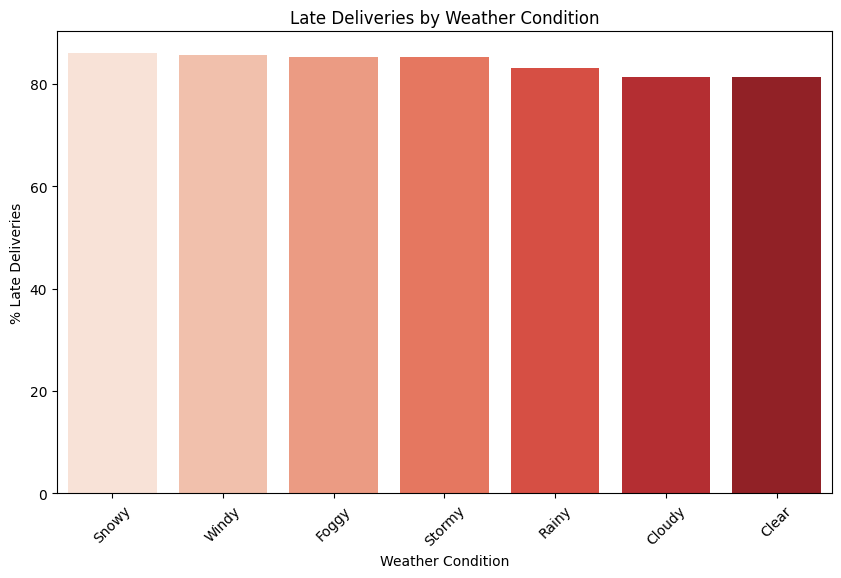

C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\998530414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=metric, data=df, palette="Reds")


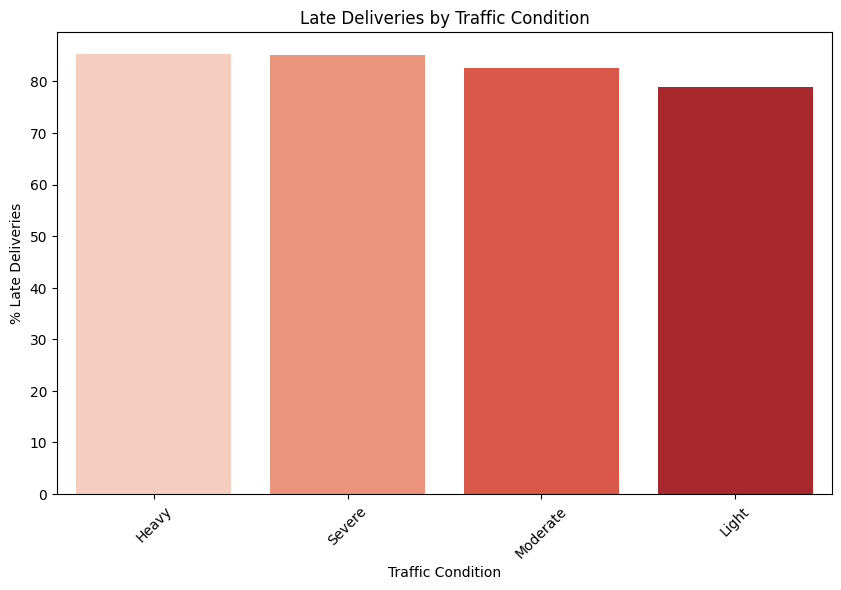

C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\998530414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=metric, data=df, palette="Reds")


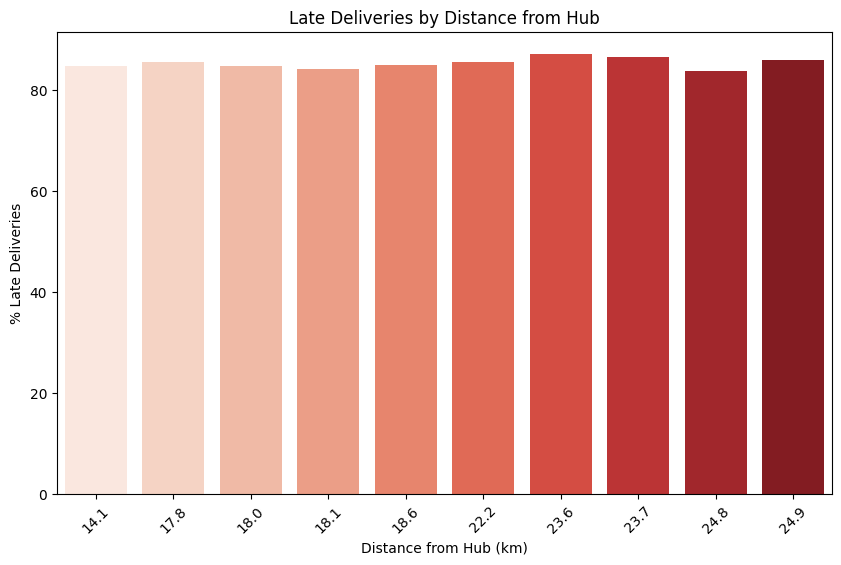

In [259]:


def plot_func(df, metric, title, ylabel,xlabel):
    plt.figure(figsize=(10,6))
    sns.barplot(x=df.index, y=metric, data=df, palette="Reds")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.xticks(rotation=45)
    plt.show()

plot_func(agg_weather,"pct_late", "Late Deliveries by Weather Condition","% Late Deliveries","Weather Condition")
plot_func(agg_traffic,"pct_late", "Late Deliveries by Traffic Condition","% Late Deliveries","Traffic Condition")
plot_func(agg_distance_p ,"pct_late", "Late Deliveries by Distance from Hub", "% Late Deliveries","Distance from Hub (km)")

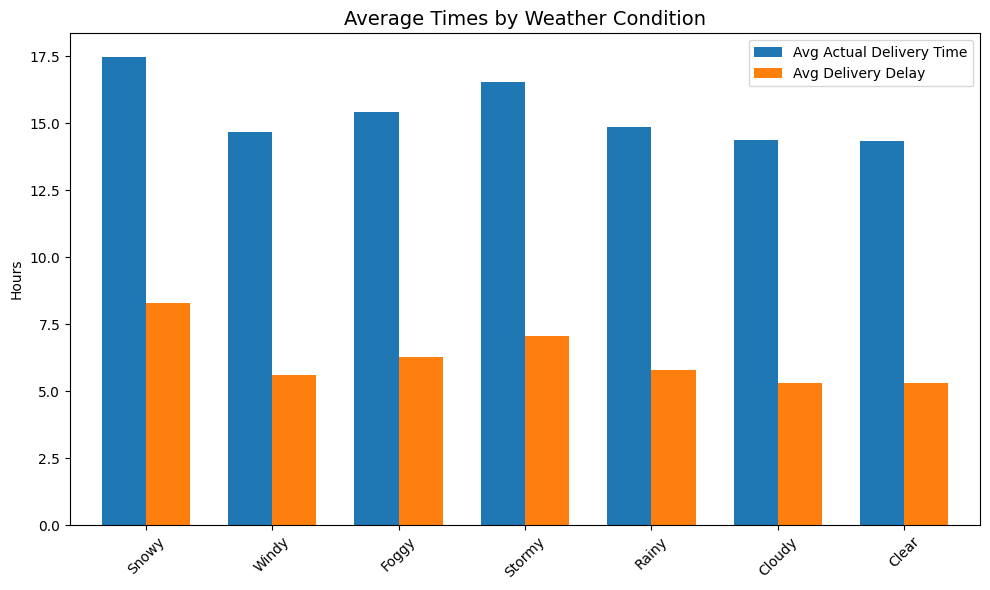

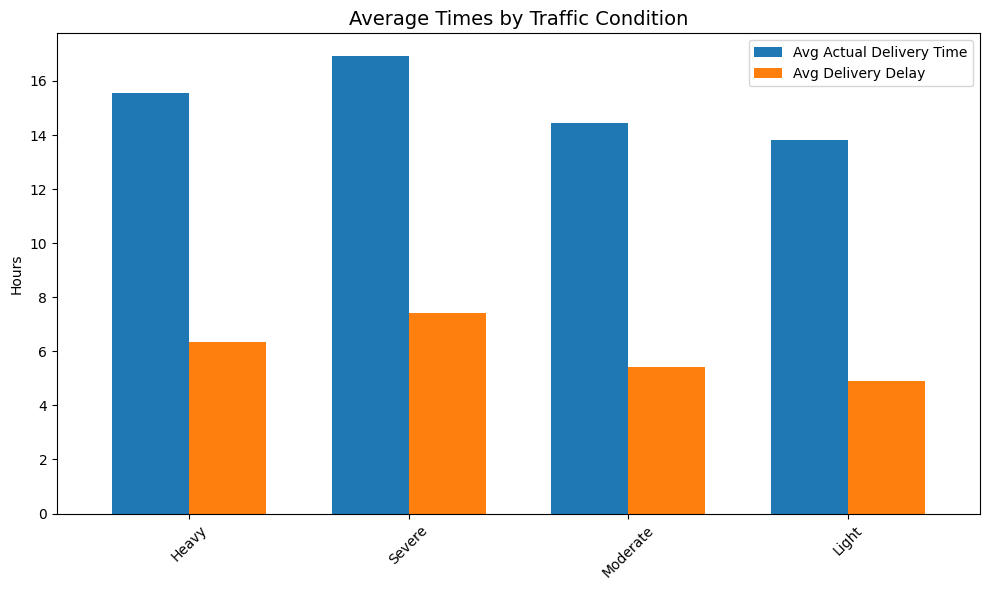

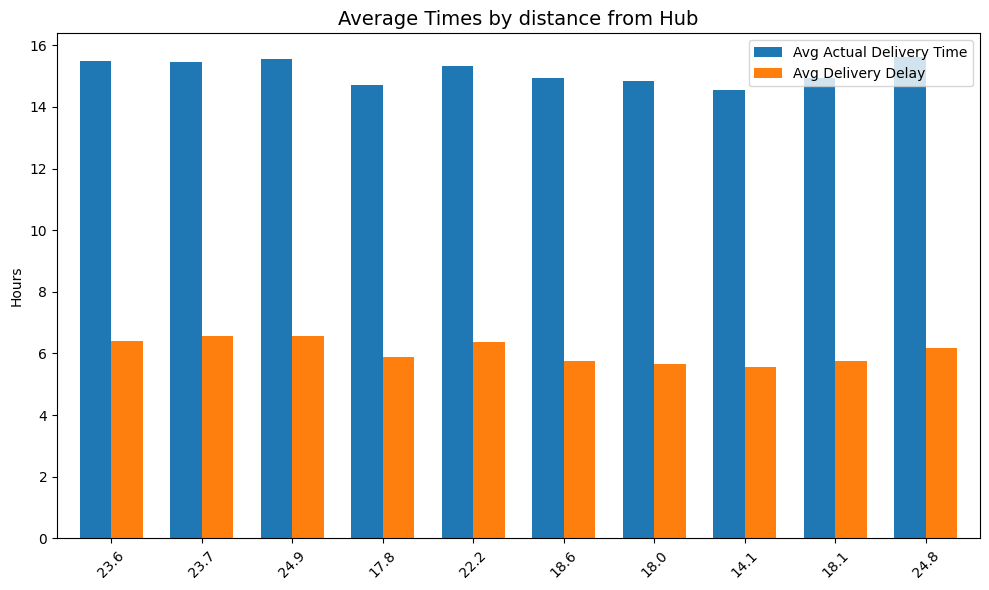

In [256]:


def plot_avg_times(agg_df, title):
    ax = agg_df[["avg_actual_time", "avg_delivery_delay"]].plot(
        kind="bar", figsize=(10,6), width=0.7
    )
    plt.title(title, fontsize=14)
    plt.ylabel("Hours")
    plt.xlabel("")
    plt.xticks(rotation=45)
    plt.legend(["Avg Actual Delivery Time", "Avg Delivery Delay"])
    plt.tight_layout()
    plt.show()

# Usage examples:
plot_avg_times(agg_weather, "Average Times by Weather Condition")
plot_avg_times(agg_traffic, "Average Times by Traffic Condition")
plot_avg_times(agg_distance_p, "Average Times by distance from Hub")



 ## Identify Worst Zones

#### Top 5 worst performing zone by Avergae rating

In [192]:
def worst_performing_zones(sort_by="pct_late", top_n=5, asc=False):
    agg_zones = aggregate_performance(merged_df, "zone_name", sort_by , asc)
    worst_zones = agg_zones.head(top_n)
    return worst_zones

worst_performing_zones("avg_rating",5,True)

,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating
zone_name,,,,,,,
Zone 7,1515,25.849937,14.547519,22039.491333,84.16,3.44,1.987491
Zone 24,1545,15.561515,6.562934,10139.733333,85.83,3.58,2.719268
Zone 12,1558,15.605359,6.181320,9630.496667,83.76,3.52,2.735314
Zone 6,1459,15.447889,6.564939,9578.246667,86.50,3.41,2.774745
Zone 28,1482,15.327260,6.366579,9435.270000,85.36,3.42,2.796942


#### Top 5 worst performing zone by Late percentage

In [190]:
worst_performing_zones("pct_late")

,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating
zone_name,,,,,,,
Zone 4,1468,15.473270,6.405593,9403.410000,87.06,3.45,2.820458
Zone 13,1484,14.720903,5.971465,8861.653333,86.86,3.48,2.932857
Zone 6,1459,15.447889,6.564939,9578.246667,86.50,3.41,2.774745
Zone 24,1545,15.561515,6.562934,10139.733333,85.83,3.58,2.719268
Zone 28,1482,15.327260,6.366579,9435.270000,85.36,3.42,2.796942


#### Top 5 worst performing zone by  Average_delivery_delay

In [193]:
worst_performing_zones("avg_delivery_delay")

,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating
zone_name,,,,,,,
Zone 7,1515,25.849937,14.547519,22039.491333,84.16,3.44,1.987491
Zone 6,1459,15.447889,6.564939,9578.246667,86.50,3.41,2.774745
Zone 24,1545,15.561515,6.562934,10139.733333,85.83,3.58,2.719268
Zone 4,1468,15.473270,6.405593,9403.410000,87.06,3.45,2.820458
Zone 28,1482,15.327260,6.366579,9435.270000,85.36,3.42,2.796942


### - Are there specific delivery zones with consistently poor performance?
Yes, there are **specific delivery zones with consistently poor performance**:

- **Zone 7**  
  - Worst in both **average delivery delay (14.5h)** and **lowest customer rating (1.98/5)**.  
  - Indicates both operational and customer satisfaction issues.  

- **Zones 4, 6, 24, and 28**  
  - Consistently appear across all three metrics (high lateness %, long delays, low ratings).  
  - Lateness rates are above **85%**, and customer ratings are below **3.0/5**.  

- **Zone 13**  
  - Not the worst on delay, but very high late % (86.9%).  

C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\998530414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=metric, data=df, palette="Reds")


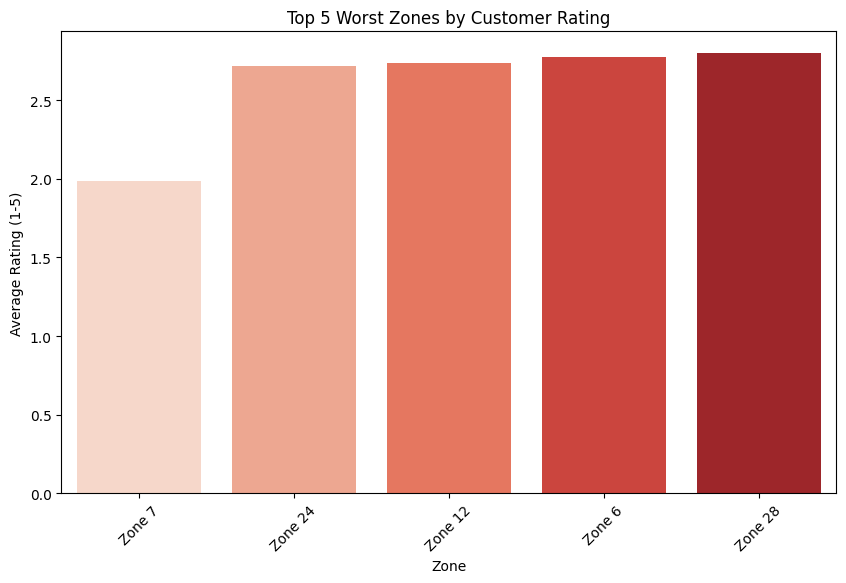

C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\998530414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=metric, data=df, palette="Reds")


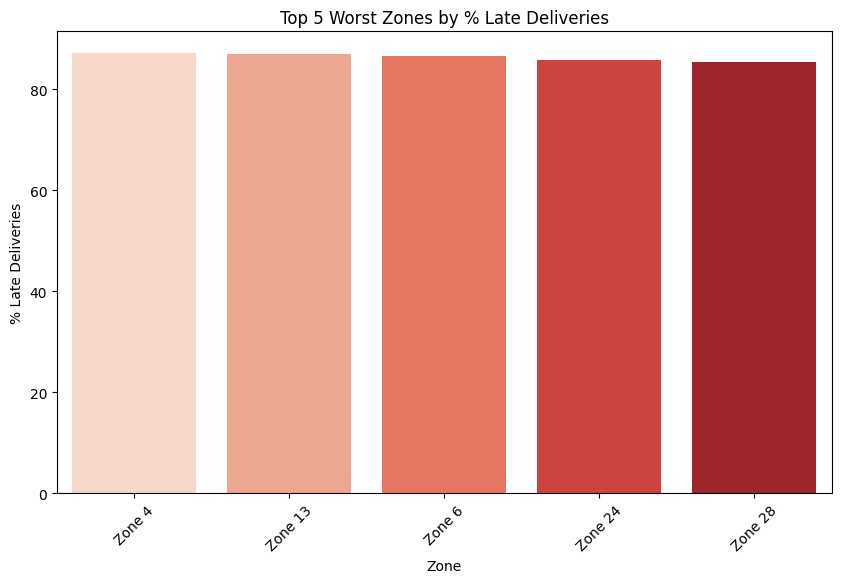

C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\998530414.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=metric, data=df, palette="Reds")


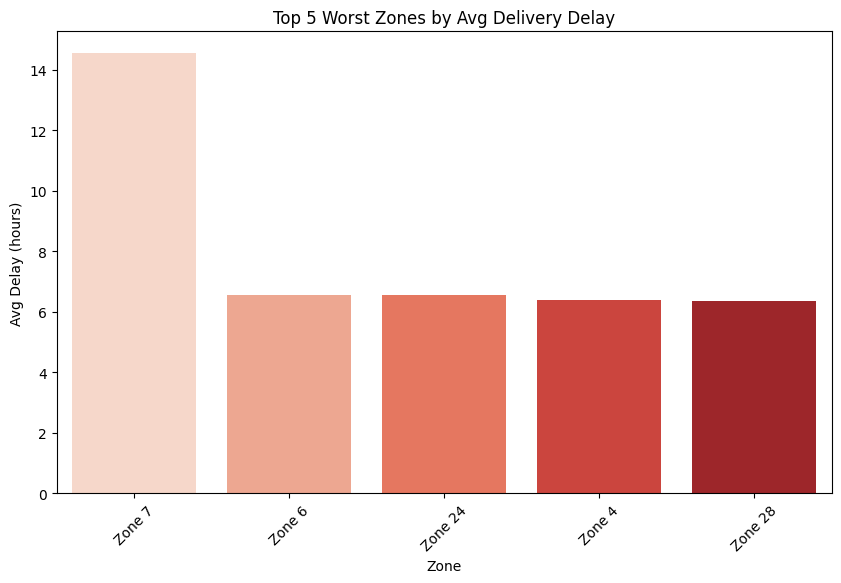

In [260]:
worst_by_rating = worst_performing_zones("avg_rating", 5, True)
worst_by_late   = worst_performing_zones("pct_late", 5, False)
worst_by_delay  = worst_performing_zones("avg_delivery_delay", 5, False)

plot_func(worst_by_rating, "avg_rating", "Top 5 Worst Zones by Customer Rating", "Average Rating (1-5)","Zone")
plot_func(worst_by_late, "pct_late", "Top 5 Worst Zones by % Late Deliveries", "% Late Deliveries", "Zone")
plot_func(worst_by_delay, "avg_delivery_delay", "Top 5 Worst Zones by Avg Delivery Delay", "Avg Delay (hours)", "Zone")

# More Exploration

In [261]:
def plot_performance(df, metric, title, ylabel, top_n=10):
    df_plot = df.reset_index().head(top_n)  # reset index so group_col becomes a column
    plt.figure(figsize=(10,6))
    sns.barplot(x=df_plot.columns[0], y=metric, data=df_plot, palette="Blues")
    plt.title(title, fontsize=14)
    plt.ylabel(ylabel)
    plt.xlabel("")
    plt.xticks(rotation=45)
    plt.show()


### Driver Performance

This analysis identifies drivers with the **highest and lowest performance**.  
Driver performance can be evaluated using multiple criteria, such as:  

- **Average customer ratings** (service quality)  
- **Average delivery delay** (timeliness)  
- **% of late deliveries** (reliability)  

Here i identify top performer drivers based on a single criterion (% of late deliveries).  
However, driver performance can also be explored using other metrics such as average delivery delay and avg_ratings for a more complete evaluation.   


,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
driver_id,,,,,,,,,,
D042,880,10.291527,3.107873,2734.928000,44.77,1.06,3.113390,25.147846,-12.584941,1.671810
D024,872,14.903716,5.478616,4777.353333,80.39,1.89,3.099879,25.316153,-7.925581,1.523621
D005,872,15.111170,5.723983,4991.313333,80.62,1.90,3.142686,25.228834,-8.061955,1.584205
D043,909,14.669791,5.571412,5064.413333,81.30,2.00,3.094186,25.310058,-8.094762,1.454064
D044,913,14.827119,5.505674,5026.680000,81.38,2.01,3.196408,25.552410,-7.995843,1.748460
D004,931,14.618045,5.306785,4940.616667,81.42,2.05,3.141391,24.842827,-8.438781,1.430756
D041,911,14.762130,5.865499,5343.470000,81.45,2.00,3.110465,25.407161,-8.241581,1.443479
D011,842,14.873682,5.550918,4673.873333,81.47,1.85,3.062189,25.561020,-6.773271,1.738153
D036,894,15.130089,5.616391,5021.053333,81.54,1.97,3.051342,25.677059,-6.633495,1.618924


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,3.108,D042,6.162,D023,3.054
pct_late,44.770,D042,85.600,D040,40.830
avg_rating,3.051,D036,3.204,D019,0.152


C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\4110527163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_plot.columns[0], y=metric, data=df_plot, palette=palette)


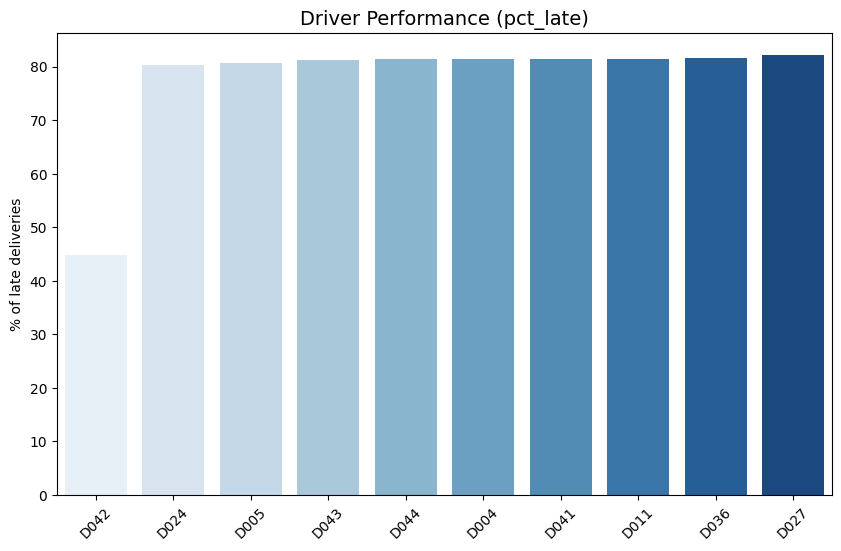

In [229]:
agg_driver = aggregate_performance(merged_df, "driver_id", sort_by="pct_late", asc=True )
display(agg_driver.head(10))

ranges=metrics_summary(
    merged_df,
    "driver_id",
    ["avg_delivery_delay", "pct_late", "avg_rating"]
)
display(ranges) # it will help us to identify influential matrics 

plot_performance(agg_driver, "pct_late", "Driver Performance (pct_late)", "% of late deliveries")


### Warehouse Efficiency

I have tried to explore if warehouse has any significant influance regarding delivery delay ,Customer rating lateness %. But warehouses have very little influence on delay, lateness %, or customer satisfaction. In other words, performance is consistent across all warehouses — the bottlenecks are not warehouse-related.

,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
warehouse_id,,,,,,,,,,
W03,5711,14.748561,5.688786,32488.658667,82.38,12.71,3.109389,25.193726,-8.000027,1.529449
W02,5570,14.747812,5.685495,31668.205333,82.53,12.41,3.114530,25.193121,-7.505299,1.561731
W05,5578,14.757122,5.681860,31693.412667,82.16,12.38,3.126292,25.225366,-7.464735,1.552750
W08,5556,14.777121,5.663503,31466.423333,82.13,12.32,3.114445,25.307450,-7.736654,1.585765
W07,5612,14.787964,5.652216,31720.236000,82.31,12.47,3.130751,24.928266,-7.847420,1.574168
W01,5580,14.634151,5.636746,31453.042000,82.51,12.43,3.119547,25.345491,-7.244714,1.562870
W06,5612,14.840419,5.632581,31610.043333,81.91,12.41,3.108169,24.990923,-7.810481,1.552412
W04,5781,14.520374,5.517805,31898.433333,82.41,12.86,3.110829,25.140736,-7.438719,1.505528


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,5.518,W04,5.689,W03,0.171
pct_late,81.910,W06,82.530,W02,0.620
avg_rating,3.108,W06,3.131,W07,0.023
avg_profit,-8.000,W03,-7.245,W01,0.755


C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\4110527163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_plot.columns[0], y=metric, data=df_plot, palette=palette)


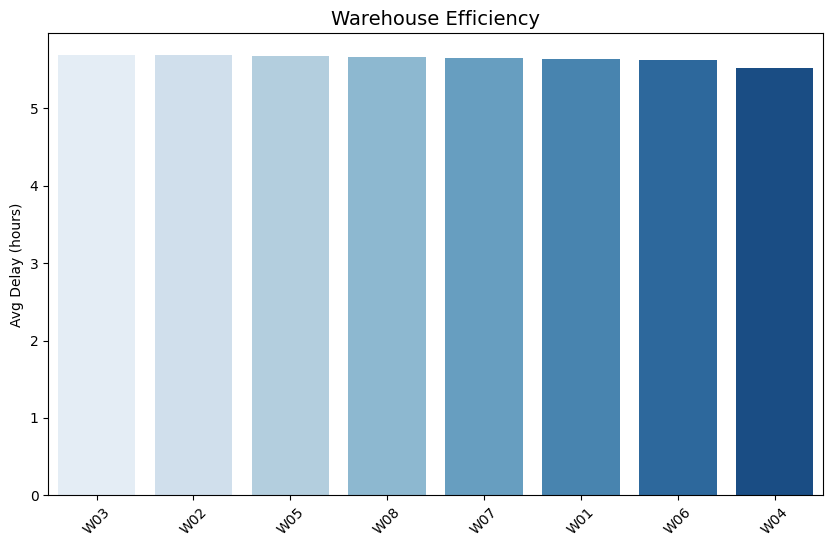

In [233]:
agg_warehouse = aggregate_performance(merged_df, "warehouse_id", sort_by="avg_delivery_delay", asc=False)
display(agg_warehouse.head(8))
ranges=metrics_summary(
    merged_df,
    "warehouse_id",
    ["avg_delivery_delay", "pct_late", "avg_rating","avg_profit"]
)
display(ranges) # it will help us to identify influential matrics
plot_performance(agg_warehouse, "avg_delivery_delay", "Warehouse Efficiency", "Avg Delay (hours)")


# Zone Dynamics
Tests whether zone type (residential, commercial, industrial) or parking difficulty explains poor delivery performance

,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
zone_type,,,,,,,,,,
Mixed,12026,15.712356,6.488253,78027.734667,82.21,26.70,3.011007,24.961513,-8.533019,1.524340
Residential,10538,14.520519,5.555516,58544.023333,83.13,23.66,3.096532,26.147051,-7.169648,1.691520
Industrial,11952,14.281308,5.248734,62732.863333,81.26,26.23,3.219085,24.340641,-7.383520,1.419831
Commercial,10484,14.307742,5.216886,54693.833333,82.73,23.42,3.141575,25.351824,-7.349354,1.597234


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,5.217,Commercial,6.488,Mixed,1.271
pct_late,81.260,Industrial,83.130,Residential,1.870
avg_rating,3.011,Mixed,3.219,Industrial,0.208


C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\4110527163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_plot.columns[0], y=metric, data=df_plot, palette=palette)


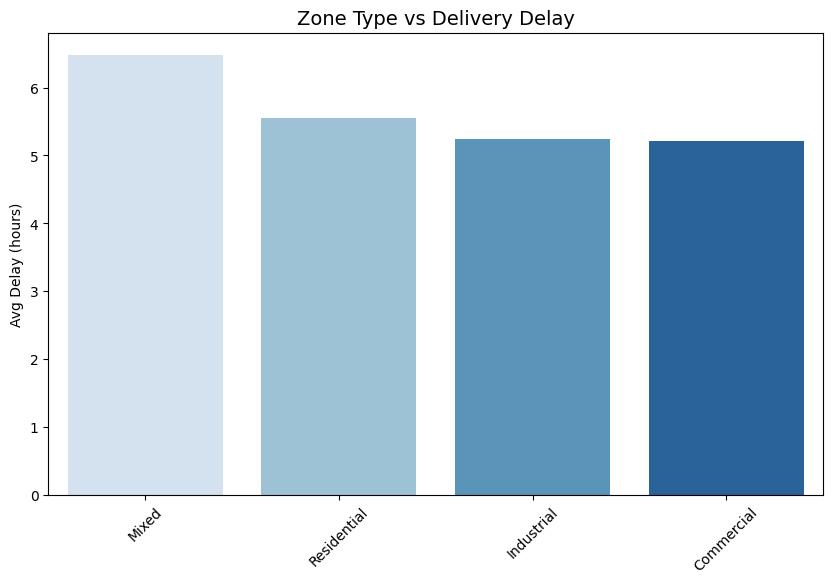

In [231]:
agg_zone_type = aggregate_performance(merged_df, "zone_type", sort_by="avg_delivery_delay", asc=False)
display(agg_zone_type.head(10))
ranges=metrics_summary(
    merged_df,
    "zone_type",
    ["avg_delivery_delay", "pct_late", "avg_rating"]
)
display(ranges) # it will help us to identify influential matrics


plot_performance(agg_zone_type, "avg_delivery_delay", "Zone Type vs Delivery Delay", "Avg Delay (hours)")



,n,avg_actual_time,avg_delivery_delay,Total_delivery_delay,pct_late,late_count,avg_rating,avg_cost,avg_profit,avg_fuel
parking_difficulty,,,,,,,,,,
5.0,6085,16.976370,7.401443,45037.781333,81.89,13.46,2.961011,22.806420,-10.038635,1.159435
4.0,13363,14.836097,5.832113,77934.523333,84.40,30.46,2.992916,28.632791,-6.778017,2.141096
3.0,8975,14.368789,5.275690,47349.313333,82.14,19.91,3.104570,25.976443,-7.032785,1.671117
2.0,6016,14.263652,5.210823,31348.310000,81.02,13.16,3.227241,23.780817,-7.990977,1.348320
1.0,10561,13.856698,4.954884,52328.526667,80.71,23.02,3.308640,22.217508,-7.636337,1.049698


,min_val,min_group,max_val,max_group,range
metric,,,,,
avg_delivery_delay,4.955,1.0,7.401,5.0,2.447
pct_late,80.710,1.0,84.400,4.0,3.690
avg_rating,2.961,5.0,3.309,1.0,0.348


C:\Users\Asus\AppData\Local\Temp\ipykernel_18892\4110527163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_plot.columns[0], y=metric, data=df_plot, palette=palette)


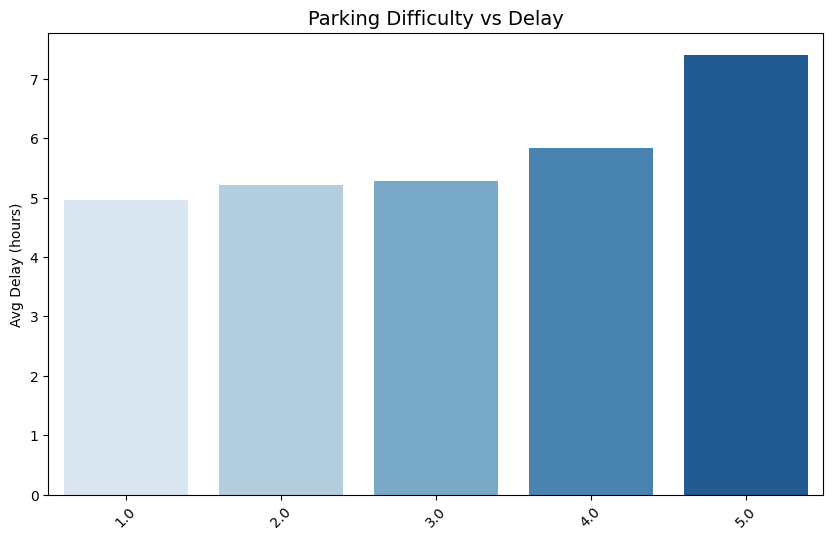

In [232]:
agg_parking = aggregate_performance(merged_df, "parking_difficulty", sort_by="avg_delivery_delay", asc=False)
display(agg_parking.head(10))
ranges=metrics_summary(
    merged_df,
    "parking_difficulty",
    ["avg_delivery_delay", "pct_late", "avg_rating"]
)
display(ranges) # it will help us to identify influential matrics


plot_performance(agg_parking, "avg_delivery_delay", "Parking Difficulty vs Delay", "Avg Delay (hours)")


Zone type has moderate impact (mixed and residential are worse).

Parking difficulty has strong impact (higher difficulty = longer delays + lower ratings).

#### Exploration still going on......